In [179]:
import numpy as np
import pandas as pd
import geopandas as gpd
import statsmodels.api as sm
from statsmodels.formula.api import ols
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import rasterio
from rasterio import features
from rasterio.windows import from_bounds
from sklearn.ensemble import RandomForestClassifier
import scipy.stats as stats
from statsmodels.stats.multicomp import pairwise_tukeyhsd

#### Config

In [180]:
config = {
    'bands': [1, 2, 3, 4, 5],
    'red_index': 2,    
    'nir_index': 4,    
    'class_field': 'layer',
    'class_map': {'bare': 1, 'veg': 2, 'salt': 3},
    'bbox': (514040, 7759022, 514346, 7759329), # min_x, min_y, max_x, max_y
    'rf_estimators': 100,
    'random_seed': 42,
    'n_samples': 100,
    'roi_path': '../data/raw/vectors/SDH1_rois_v2.gpkg',

    # list of seasons to process in the loop
    'seasons': [
        # {
        #     'name': 'november_2024', 
        #     'path': '../data/processed/orthomosaics/2024-11-08_norte-1_orthomosaic.tif'
        # },
        {
            'name': 'april_2025', 
            'path': '../data/processed/orthomosaics/2025-04-29_norte-1_orthomosaic.tif'
        },
        {
            'name': 'july_2025', 
            'path': '../data/processed/orthomosaics/2025-07-12_norte-1_orthomosaic.tif'
        },
        # {
        #     'name': 'november_2025', 
        #     'path': '../data/processed/orthomosaics/2025-11-20_norte-1_orthomosaic.tif'
        # }
    ]
}

# set global seed for numpy sampling
np.random.seed(config['random_seed'])

#### Utils

In [189]:
def load_raster_by_extent(image_path, bands, bbox):
    """
    loads a portion of the raster based on geographic coordinates (bounding box).
    """
    with rasterio.open(image_path) as src:
        window = from_bounds(*bbox, transform=src.transform)
        subset = src.read(bands, window=window, boundless=False).astype('float32')
        
        _, actual_height, actual_width = subset.shape
        
        if src.nodata is not None:
            valid_mask = ~np.all(subset == src.nodata, axis=0)
        else:
            valid_mask = ~np.all(subset == 0, axis=0)
            
        meta = src.profile.copy()
        meta.update({
            'height': actual_height,
            'width': actual_width,
            'transform': src.window_transform(window),
            'count': len(bands)
        })
        
    return subset, valid_mask, meta


def calculate_ndvi(red_array, nir_array, valid_mask):
    """
    calculates normalized difference vegetation index (ndvi).
    """
    ndvi = np.full(red_array.shape, np.nan, dtype=np.float32)
    denominator = nir_array + red_array
    calc_mask = valid_mask & (denominator != 0)
    
    ndvi[calc_mask] = (nir_array[calc_mask] - red_array[calc_mask]) / denominator[calc_mask]
    return ndvi


def prepare_training_mask(roi_path, raster_meta, class_field, class_map):
    """
    loads vectors, matches crs, and rasterizes them into a training label mask.
    """
    gdf = gpd.read_file(roi_path)
    crs_raster = raster_meta['crs']
    
    if gdf.crs is None:
        gdf.set_crs(crs_raster, inplace=True)
    elif gdf.crs != crs_raster:
        gdf = gdf.to_crs(crs_raster)
        
    gdf['class_id'] = gdf[class_field].map(class_map)
    out_shape = (raster_meta['height'], raster_meta['width'])
    
    train_mask = features.rasterize(
        [(shape, label) for shape, label in zip(gdf.geometry, gdf['class_id'])],
        out_shape=out_shape,
        transform=raster_meta['transform'],
        fill=0,
        dtype='uint8'
    )
    return train_mask


def train_and_predict_rf(image_array, train_mask, valid_mask, n_estimators, seed):
    """
    fits a random forest model using valid training pixels and predicts the valid area.
    """
    n_bands = image_array.shape[0]
    X_all = image_array.reshape(n_bands, -1).T
    y_all = train_mask.ravel()
    
    train_indices = (y_all > 0) & (valid_mask.ravel())
    X_train = X_all[train_indices]
    y_train = y_all[train_indices]
    
    rf = RandomForestClassifier(n_estimators=n_estimators, n_jobs=-1, random_state=seed)
    rf.fit(X_train, y_train)
    
    X_to_predict = X_all[valid_mask.ravel()]
    prediction_flat = rf.predict(X_to_predict)
    
    classification = np.zeros(y_all.shape, dtype='uint8')
    classification[valid_mask.ravel()] = prediction_flat
    
    return classification.reshape(train_mask.shape)


def extract_spatial_samples(class_array, ms_array, ndvi_array, valid_mask, n_points, season_name, seed):
    """
    generates random spatial samples and includes the season name for time-series analysis.
    """
    records = []
    point_id = 0
    unique_classes = [c for c in np.unique(class_array[valid_mask]) if c > 0]
    
    # local random generator
    rng = np.random.default_rng(seed)

    for class_val in unique_classes:
        row_idx, col_idx = np.where((class_array == class_val) & valid_mask)
        n_samples = min(n_points, len(row_idx))
        
        random_choices = rng.choice(len(row_idx), n_samples, replace=False)
        
        for idx in random_choices:
            r, c = row_idx[idx], col_idx[idx]
            records.append({
                'point_id': point_id,
                'class_id': class_val,
                'season': season_name,
                'ndvi': ndvi_array[r, c],
                'b1_blue': ms_array[0, r, c],
                'b2_green': ms_array[1, r, c],
                'b3_red': ms_array[2, r, c],
                'b4_rededge': ms_array[3, r, c],
                'b5_nir': ms_array[4, r, c]
            })
            point_id += 1
            
    return pd.DataFrame(records)


def append_effect_size_to_tukey(tukey_res, df_clean, val_col='ndvi', group_col='group_compare'):
    """
    extracts tukey results into a dataframe and calculates cohen's d for each pair.
    """
    # convert tukey summary to dataframe
    tukey_data = tukey_res._results_table.data
    df_tukey = pd.DataFrame(tukey_data[1:], columns=tukey_data[0])
    
    cohens_d_values = []
    
    for _, row in df_tukey.iterrows():
        group1 = row['group1']
        group2 = row['group2']
        
        data1 = df_clean[df_clean[group_col] == group1][val_col]
        data2 = df_clean[df_clean[group_col] == group2][val_col]
        
        # calculate pooled standard deviation
        n1, n2 = len(data1), len(data2)
        var1, var2 = np.var(data1, ddof=1), np.var(data2, ddof=1)
        pooled_std = np.sqrt(((n1 - 1) * var1 + (n2 - 1) * var2) / (n1 + n2 - 2))
        
        # calculate absolute cohens d
        d = abs(np.mean(data2) - np.mean(data1)) / pooled_std
        cohens_d_values.append(round(d, 4))
        
    df_tukey['cohens_d'] = cohens_d_values
    
    # evaluate effect size magnitude
    conditions = [
        (df_tukey['cohens_d'] < 0.2),
        (df_tukey['cohens_d'] >= 0.2) & (df_tukey['cohens_d'] < 0.5),
        (df_tukey['cohens_d'] >= 0.5) & (df_tukey['cohens_d'] < 0.8),
        (df_tukey['cohens_d'] >= 0.8)
    ]
    choices = ['negligible', 'small', 'medium', 'large']
    df_tukey['effect_size'] = np.select(conditions, choices, default='unknown')
    
    return df_tukey


def analyze_master_statistics(df_master, reverse_mapping, alpha=0.05):
    """
    calculates stats per class/season and runs anova/tukey across all temporal-class groups.
    """
    print("\n" + "="*40)
    print("MASTER STATISTICAL ANALYSIS REPORT")
    print("="*40)
    
    df_clean = df_master.dropna(subset=['ndvi']).copy()
    df_clean['class_name'] = df_clean['class_id'].map(reverse_mapping)
    
    # 1. basic statistics per cover AND season
    stats_summary = df_clean.groupby(['class_name', 'season'])['ndvi'].agg(
        count='count', mean='mean', median='median', std='std', min='min', max='max'
    ).reset_index()
    
    print("\n--- DESCRIPTIVE STATISTICS PER CLASS & SEASON ---")
    print(stats_summary.to_string(index=False))
    
    # ONE-WAY ANOVA
    # # 2. combine class and season for cross-comparison
    # df_clean['group_compare'] = df_clean['class_name'] + "_" + df_clean['season']
    # unique_groups = df_clean['group_compare'].unique()
    # ndvi_groups = [df_clean[df_clean['group_compare'] == grp]['ndvi'] for grp in unique_groups]
    
    # # 3. anova test
    # f_stat, p_value = stats.f_oneway(*ndvi_groups)
    
    # print(f"\n--- ANOVA RESULTS (ACROSS CLASSES AND SEASONS) ---")
    # print(f"f-statistic: {f_stat:.4f} | p-value: {p_value:.4e}")
    
    # # 4. post hoc test
    # if p_value < alpha:
    #     print(f"\nResult: significant differences detected (p < {alpha}).")
    #     print("--- TUKEY HSD POST HOC TEST ---")
    #     tukey_res = pairwise_tukeyhsd(
    #         endog=df_clean['ndvi'], 
    #         groups=df_clean['group_compare'], 
    #         alpha=alpha
    #     )
    #     print(tukey_res)
    # else:
    #     print(f"\nResult: no significant differences found (p >= {alpha}).")

    # TWO-WAY ANOVA
    model = ols('ndvi ~ C(class_name) + C(season) + C(class_name):C(season)', data=df_clean).fit()
    anova_table = sm.stats.anova_lm(model, typ=2)
    
    print(f"\n--- TWO-WAY ANOVA RESULTS ---")
    print(anova_table)
    
    interaction_p_value = anova_table.loc['C(class_name):C(season)', 'PR(>F)']
    
    # 2. combine class and season for cross-comparison in tukey
    df_clean['group_compare'] = df_clean['class_name'] + "_" + df_clean['season']
    
    # MODIFIED: USED INTERACTION P-VALUE INSTEAD OF OVERALL P-VALUE TO TRIGGER POST HOC
    if interaction_p_value < alpha:
        print(f"\nResult: significant interaction detected (p < {alpha}).")
        print("--- TUKEY HSD POST HOC TEST WITH EFFECT SIZE (COHEN D) ---")
        tukey_res = pairwise_tukeyhsd(
            endog=df_clean['ndvi'], 
            groups=df_clean['group_compare'], 
            alpha=alpha
        )
        df_tukey_enhanced = append_effect_size_to_tukey(tukey_res, df_clean)
        print(df_tukey_enhanced.to_string(index=False))

    else:
        print(f"\nResult: no significant interaction found (p >= {alpha}).")

    return stats_summary


def get_clean_stretch(band_array, valid_mask, p_low=2, p_high=98):
    """
    applies a percentile stretch to a band for rgb visualization.
    """
    valid_pixels = band_array[valid_mask]
    
    if valid_pixels.size == 0:
        return np.zeros_like(band_array)
        
    low, high = np.percentile(valid_pixels, (p_low, p_high))
    stretched = np.clip(band_array, low, high)
    
    if high - low == 0:
        return np.zeros_like(band_array)
        
    return (stretched - low) / (high - low)


def plot_rgb_and_classification(subset, classification, valid_mask, season_name, class_map):
    """
    plots the rgb true color composite and the random forest classification side by side.
    """
    # stretch rgb bands (assumes band 2=red, 1=green, 0=blue based on array index)
    red_st = get_clean_stretch(subset[2], valid_mask)
    green_st = get_clean_stretch(subset[1], valid_mask)
    blue_st = get_clean_stretch(subset[0], valid_mask)
    
    rgb = np.dstack((red_st, green_st, blue_st))
    rgb[~valid_mask] = 1 
    
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 8))
    
    ax1.imshow(rgb)
    ax1.set_title(f"RGB composite - {season_name.capitalize()}")
    ax1.axis('off')

    # use discrete colormap for classification
    cmap = plt.cm.get_cmap('Set1', len(class_map))

    masked_classification = np.ma.masked_where(classification == 0, classification)
    ax2.imshow(masked_classification, cmap=cmap)
    ax2.set_title(f"Classification - {season_name.capitalize()}")
    ax2.axis('off')
    
    # create custom discrete legend patches
    patches = [mpatches.Patch(color=cmap(i), label=label) 
               for i, label in enumerate(class_map.keys())]
    ax2.legend(handles=patches, loc='upper right', title="Classes")
    
    plt.tight_layout()
    plt.show()


def plot_master_ndvi_distribution(df_master, reverse_mapping):
    """
    plots ndvi distribution (violin + jitter) and overlays the mean perfectly aligned.
    """
    df_plot = df_master.copy()
    df_plot['class_name'] = df_plot['class_id'].map(reverse_mapping)
    
    plt.figure(figsize=(12, 6))
    
    # specify order to ensure perfect alignment across all 3 plot types
    order = sorted(df_plot['class_name'].unique())
    hue_order = sorted(df_plot['season'].unique())

    # monochromatic palette for violins
    grey_palette = {season: '#e0e0e0' for season in hue_order}
    
    # fix the dodge value for all layers to ensure alignment
    fixed_dodge = 0.4

    # background violin plot
    sns.violinplot(
        data=df_plot, x='class_name', y='ndvi', hue='season',
        order=order, hue_order=hue_order,
        inner=None, palette=grey_palette, alpha=0.3, dodge=fixed_dodge, linewidth=1
    )
    
    # jitter plot (stripplot)
    sns.stripplot(
        data=df_plot, x='class_name', y='ndvi', hue='season',
        order=order, hue_order=hue_order,
        dodge=fixed_dodge, alpha=0.4, palette='Set2', zorder=1
    )
    
    # mean per group
    sns.pointplot(
        data=df_plot, 
        x='class_name', 
        y='ndvi', 
        hue='season',
        order=order, 
        hue_order=hue_order,
        dodge=fixed_dodge,
        estimator='mean', 
        markers="o",
        color='black',
        err_kws={'linewidth': 0},
        linestyles="none",
        zorder=3
    )

    #plt.title('NDVI Distribution by Land Cover and Season', fontsize=14)
    plt.xlabel('Land cover', fontsize=12)
    plt.ylabel('NDVI', fontsize=12)
    
    handles, labels = plt.gca().get_legend_handles_labels()
    n_seasons = len(hue_order)
    plt.legend(handles[n_seasons:2*n_seasons], labels[n_seasons:2*n_seasons], title='Season', loc='upper left')
    
    plt.grid(axis='y', linestyle='--', alpha=0.5)
    plt.tight_layout()
    plt.show()


def plot_multiseason_spectral_signatures(df_master, reverse_mapping):
    """
    plots the mean spectral signatures per class, showing different seasons as distinct lines.
    """
    bands_cols = ['b1_blue', 'b2_green', 'b3_red', 'b4_rededge', 'b5_nir']
    band_names = ['Blue', 'Green', 'Red', 'Red Edge', 'NIR']
    
    unique_classes = sorted(df_master['class_id'].unique())
    n_classes = len(unique_classes)
    seasons = sorted(df_master['season'].unique())
    
    fig, axes = plt.subplots(1, n_classes, figsize=(6 * n_classes, 5), sharey=True)
    if n_classes == 1:
        axes = [axes]
        
    palette = sns.color_palette("Set2", n_colors=len(seasons))
    
    for ax, class_val in zip(axes, unique_classes):
        class_name = reverse_mapping.get(class_val, "Unknown")
        
        for idx, season in enumerate(seasons):
            subset = df_master[(df_master['class_id'] == class_val) & (df_master['season'] == season)]
            
            if not subset.empty:
                mean_signature = subset[bands_cols].mean().values
                ax.plot(
                    band_names, mean_signature, 
                    color=palette[idx], linewidth=3, marker='o', 
                    label=f"{season}"
                )
        
        ax.set_title(f'Spectral signatures: {class_name}', fontsize=12)
        ax.set_xlabel('Bands')
        if ax == axes[0]:
            ax.set_ylabel('Reflectance')
            
        ax.grid(True, linestyle='--', alpha=0.5)
        ax.legend(title='Season', loc='upper left')
        
    plt.tight_layout()
    plt.show()


def plot_combined_spectral_signatures(df_master):
    """
    plots mean spectral signatures for all classes and seasons in a single figure.
    seasons are differentiated by color, and land cover classes by marker type.
    """
    # 1. define band mapping
    bands_cols = ['b1_blue', 'b2_green', 'b3_red', 'b4_rededge', 'b5_nir']
    band_names = ['Blue', 'Green', 'Red', 'Red Edge', 'NIR']
    
    # 2. calculate means grouped by class and season
    df_means = df_master.groupby(['class_id', 'season'])[bands_cols].mean().reset_index()
    
    # 3. reshape to 'long' format for seaborn (tidy data)
    # this creates a row for every single band measurement
    df_long = df_means.melt(
        id_vars=['class_id', 'season'], 
        value_vars=bands_cols, 
        var_name='band_id', 
        value_name='reflectance'
    )
    
    # map band IDs to names for the X axis
    band_map = dict(zip(bands_cols, band_names))
    df_long['band_name'] = df_long['band_id'].map(band_map)
    
    # map class IDs to names for the legend
    # (using the global reverse_class_map defined in the main script)
    df_long['class_name'] = df_long['class_id'].map(reverse_class_map)

    # 4. plotting
    plt.figure(figsize=(12, 7))
    
    # sns.lineplot is perfect for this as it handles 'hue' and 'style' simultaneously
    sns.lineplot(
        data=df_long, 
        x='band_name', 
        y='reflectance', 
        hue='season',      # color by season
        style='class_name', # marker/line style by class
        markers=True,      # show dots/squares/triangles
        dashes=True,      # keep solid lines for better clarity
        linewidth=2.5,
        markersize=10,
        palette='Set2'     # vibrant colors for seasons
    )
    
    #plt.title('Combined Spectral Signatures: Multi-Temporal & Multi-Class Analysis', fontsize=14)
    plt.xlabel('Spectral bands', fontsize=12)
    plt.ylabel('Reflectance', fontsize=12)
    plt.grid(True, linestyle='--', alpha=0.6)
    
    # adjust legend location
    plt.legend(title='Season & Cover', bbox_to_anchor=(1.05, 1), loc='upper left')
    
    plt.tight_layout()
    plt.show()

#### Main


processing season: april_2025
training and predicting...


/var/folders/jv/vkj2kxvs7vs4lb9_8bnqgr2h0000gn/T/ipykernel_69602/1044860463.py:275: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap('Set1', len(class_map))


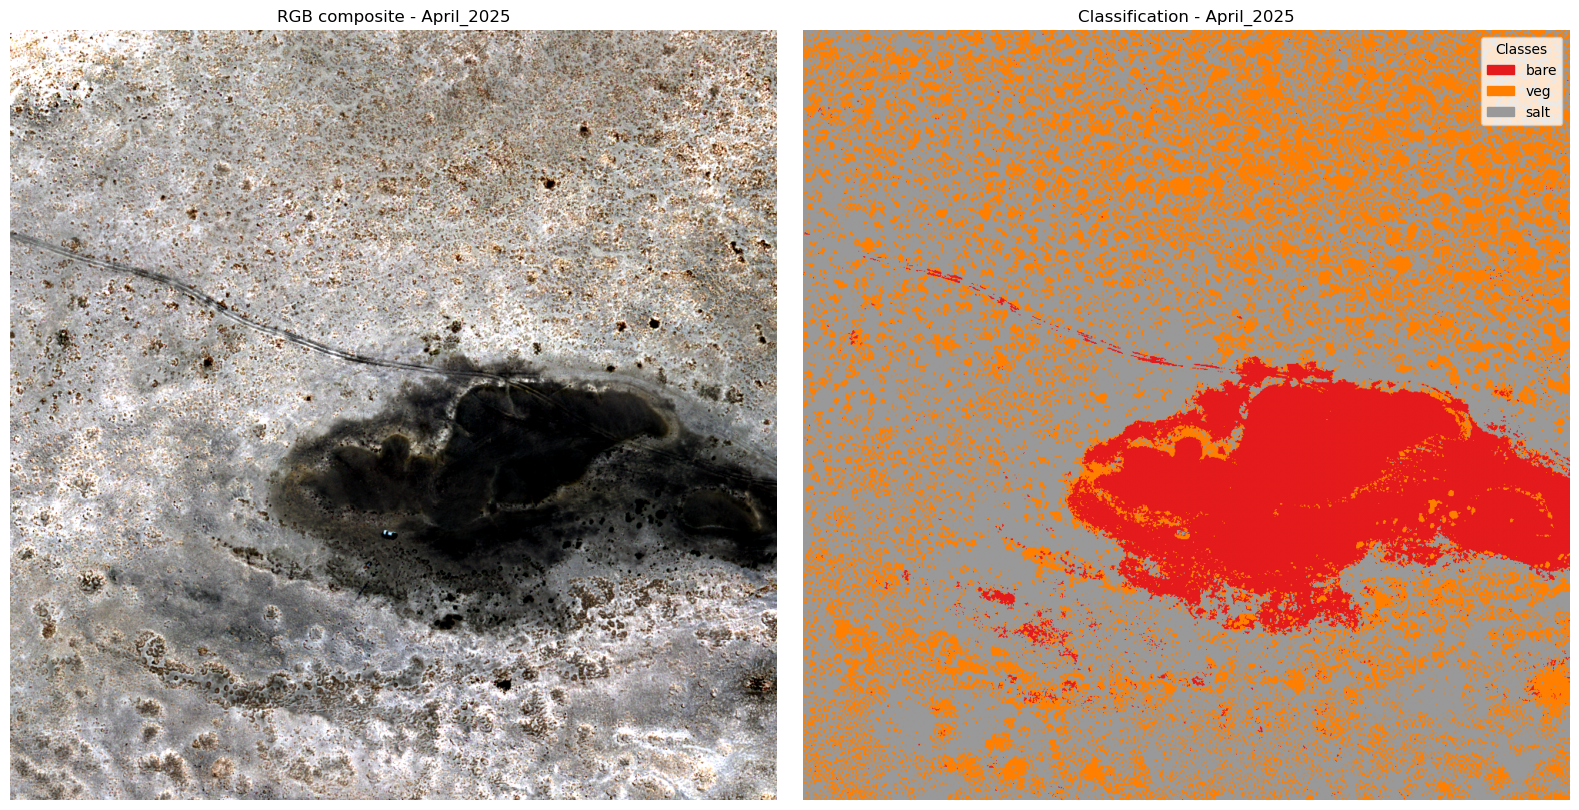


processing season: july_2025
training and predicting...


/var/folders/jv/vkj2kxvs7vs4lb9_8bnqgr2h0000gn/T/ipykernel_69602/1044860463.py:275: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap('Set1', len(class_map))


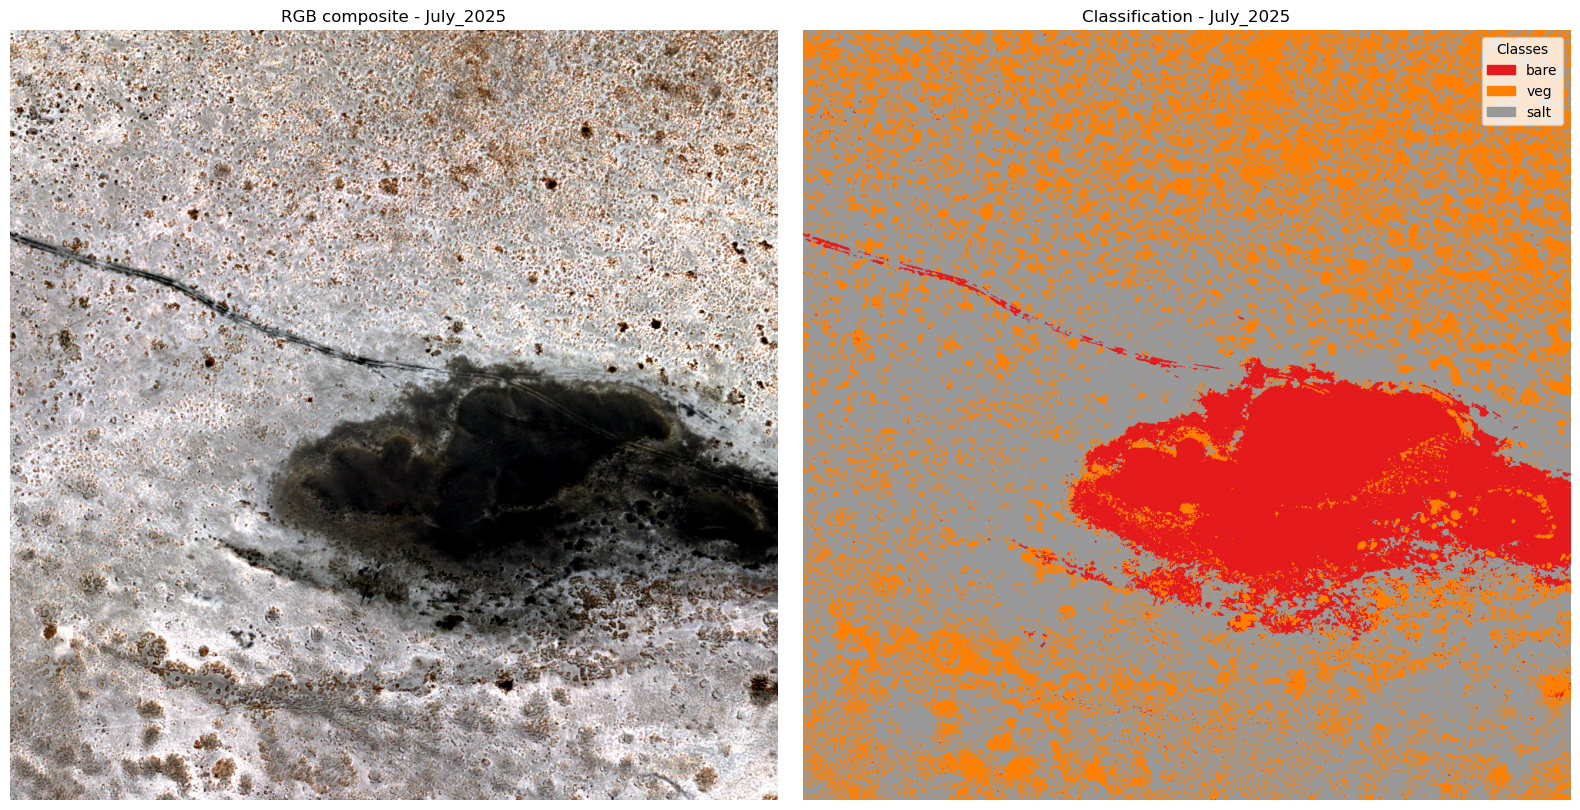


master dataframe generated. total rows: 600

MASTER STATISTICAL ANALYSIS REPORT

--- DESCRIPTIVE STATISTICS PER CLASS & SEASON ---
class_name     season  count     mean   median      std       min      max
      bare april_2025    100 0.075327 0.075802 0.014052  0.036776 0.110301
      bare  july_2025    100 0.074210 0.073741 0.013057  0.043210 0.105072
      salt april_2025    100 0.037451 0.037050 0.015010  0.001889 0.098450
      salt  july_2025    100 0.026519 0.025436 0.013024 -0.006502 0.067628
       veg april_2025    100 0.077808 0.071350 0.030325  0.038082 0.223849
       veg  july_2025    100 0.052582 0.049549 0.026781  0.014164 0.152143

--- TWO-WAY ANOVA RESULTS ---
                           sum_sq     df           F        PR(>F)
C(class_name)            0.201667    2.0  252.114468  5.355353e-80
C(season)                0.023157    1.0   57.900238  1.086953e-13
C(class_name):C(season)  0.014699    2.0   18.376030  1.805290e-08
Residual                 0.237571  594.0    

/var/folders/jv/vkj2kxvs7vs4lb9_8bnqgr2h0000gn/T/ipykernel_69602/1044860463.py:325: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:black'` for the same effect.

  sns.pointplot(


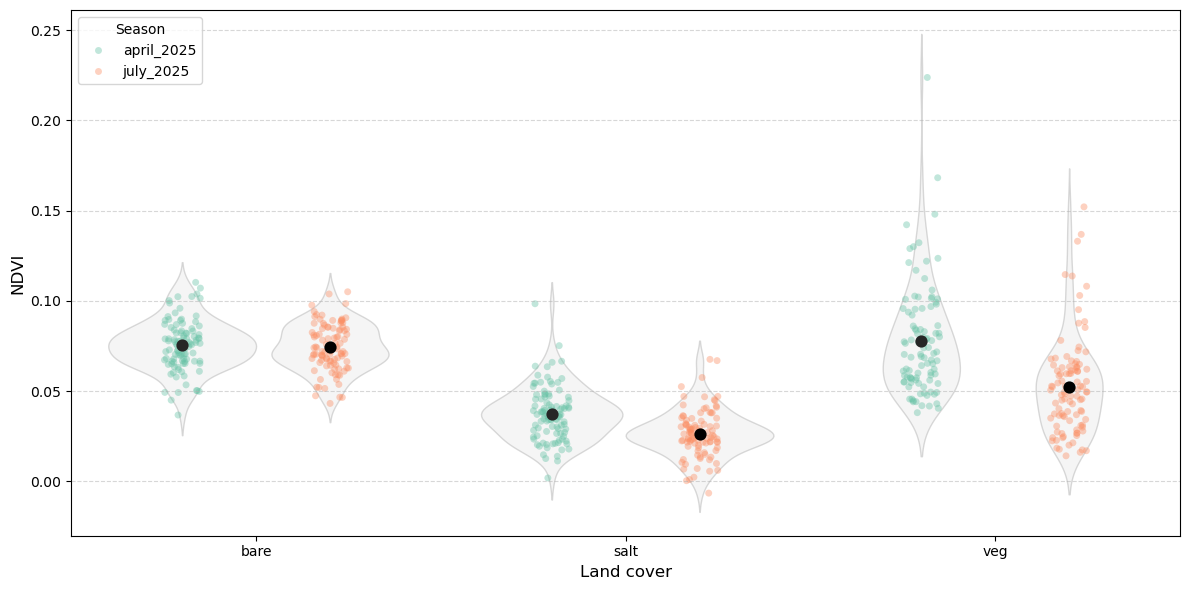

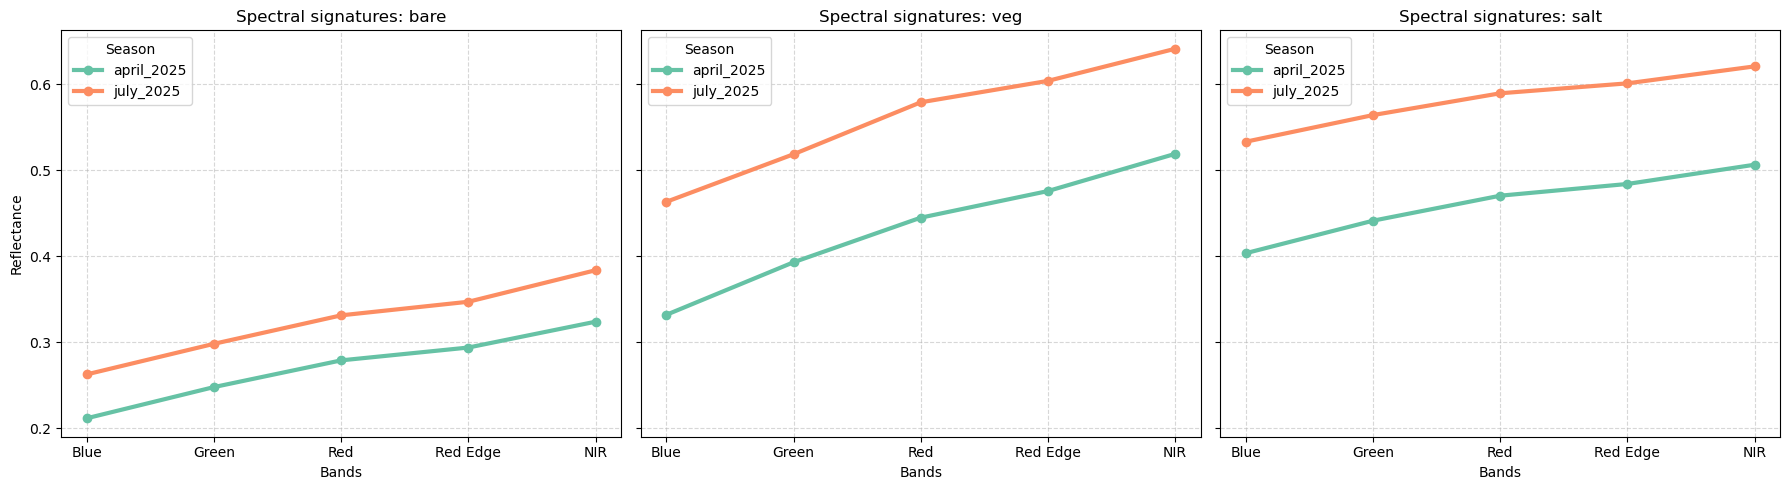

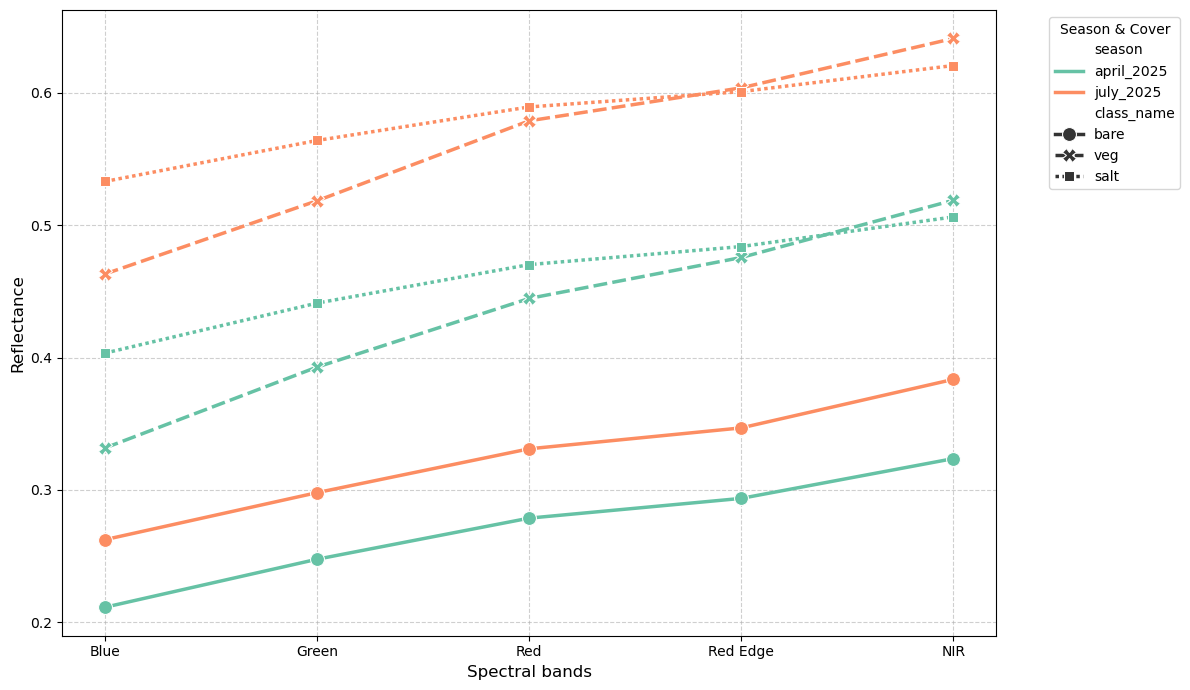

In [190]:
if __name__ == '__main__':
    
    all_season_samples = []
    
    # loop through each configured season
    for season_info in config['seasons']:
        print(f"\nprocessing season: {season_info['name']}")
        
        # load data using bbox
        ms_array, valid_mask, meta = load_raster_by_extent(
            season_info['path'], config['bands'], config['bbox']
        )
        
        # calculate indices
        red_band = ms_array[config['red_index']]
        nir_band = ms_array[config['nir_index']]
        ndvi_layer = calculate_ndvi(red_band, nir_band, valid_mask)
        
        # prepare masks and model
        train_mask = prepare_training_mask(
            config['roi_path'], meta, config['class_field'], config['class_map']
        )
        
        print("training and predicting...")
        classification = train_and_predict_rf(
            ms_array, train_mask, valid_mask, config['rf_estimators'], config['random_seed']
        )
        
        # visually inspect crops and results
        plot_rgb_and_classification(ms_array, classification, valid_mask, season_info['name'], config['class_map'])

        # extract samples and append to master list
        df_season_samples = extract_spatial_samples(
            classification, ms_array, ndvi_layer, valid_mask, 
            config['n_samples'], season_info['name'], config['random_seed']
        )
        
        all_season_samples.append(df_season_samples)
        
    # compile master dataframe
    df_master = pd.concat(all_season_samples, ignore_index=True)
    print(f"\nmaster dataframe generated. total rows: {len(df_master)}")
    
    # reverse map for readability
    reverse_class_map = {v: k for k, v in config['class_map'].items()}
    
    # run multi-temporal statistics
    stats_df = analyze_master_statistics(df_master, reverse_class_map)
    
    # plot multi-temporal distributions
    plot_master_ndvi_distribution(df_master, reverse_class_map)
    plot_multiseason_spectral_signatures(df_master, reverse_class_map)
    plot_combined_spectral_signatures(df_master)

Resultados ANOVA dos vías (50 o 100 muestras)
- No hay diferencias entre suelo de abril y julio
- No hay diferencias entre sal de abril y julio
- Hay diferencias entre vegetación de abril y julio
- Hay diferencias entre sal y vegetación, tanto en abril como en julio
- No hay diferencia entre suelo y veg en abril; sí la hay en julio (ndvi veg es menor en julio)

Resultados D de Cohen (50, 100 o 500 muestras)
- Sí hay diferencias entre sal de abril y julio (post revisión de ROIs la diferencia disminuye)
- La diferencia entre vegetación de abril y julio no es tan grande (post revisión de ROIs sí lo es) 

Pendientes:
- Validar resultados clasificación
- Revisar funcionamiento del algoritmo completo